In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score, silhouette_score
import seaborn as sns
import numpy as np
import kagglehub
import datetime
import os

In [ ]:
path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")

csv_path = os.path.join(path, "marketing_campaign.csv")
data = pd.read_csv(csv_path, sep=';')


Using Colab cache for faster access to the 'arketing-campaign' dataset.


In [ ]:
print("Number of data points : ", len(data))
data.info()

Number of data points :  2240
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDeals

In [ ]:
data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
data.isnull().any()
data = data.dropna(how='any', axis=0)

print("Number of data points wihout missing values : ", len(data))


Number of data points wihout missing values :  2216


In [ ]:
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

last_date = data['Dt_Customer'].max()
days = []

for i in data['Dt_Customer']:
    d = last_date - i
    days.append(d)

data['Customer_For'] = days
data['Customer_For'] = data['Customer_For'].astype('int64')

In [ ]:
data["Age"] = datetime.datetime.now().year - data["Year_Birth"]

data["Spent"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]

data["Amount"] = data["NumDealsPurchases"] + data["NumWebPurchases"] + data["NumCatalogPurchases"] + data["NumStorePurchases"] + data["NumDealsPurchases"]

data["Living_With"] = data["Marital_Status"].replace({"Together": "Partner", "Married": "Partner", "Divorced": "Single", "Widow": "Single", "Alone": "Single", "YOLO":"Single", "Absurd":"Single"})

data["Children"] = data["Kidhome"] + data["Teenhome"]

data["Education"] = data["Education"].replace({"Basic":"Undergraduate", "2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

data["Is_Parent"] = np.where(data["Children"] > 0, 1, 0)

to_drop = ["ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]
data = data.drop(to_drop, axis=1)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Marital_Status       2216 non-null   object 
 2   Income               2216 non-null   float64
 3   Kidhome              2216 non-null   int64  
 4   Teenhome             2216 non-null   int64  
 5   Recency              2216 non-null   int64  
 6   MntWines             2216 non-null   int64  
 7   MntFruits            2216 non-null   int64  
 8   MntMeatProducts      2216 non-null   int64  
 9   MntFishProducts      2216 non-null   int64  
 10  MntSweetProducts     2216 non-null   int64  
 11  MntGoldProds         2216 non-null   int64  
 12  NumDealsPurchases    2216 non-null   int64  
 13  NumWebPurchases      2216 non-null   int64  
 14  NumCatalogPurchases  2216 non-null   int64  
 15  NumStorePurchases    2216 non-null   int64 

In [ ]:
data.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_For,Age,Spent,Amount,Children,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,5.800993,5.319043,0.009477,0.150271,3.054423e+16,57.179603,607.075361,17.204422,0.947202,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,3.250785,2.425359,0.096907,0.357417,1.749036e+16,11.985554,602.900476,8.554655,0.749062,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,30.000000,5.000000,0.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,3.000000,3.000000,0.000000,0.000000,1.555200e+16,49.000000,69.000000,9.000000,0.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,5.000000,6.000000,0.000000,0.000000,3.071520e+16,56.000000,396.500000,17.000000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,8.000000,7.000000,0.000000,0.000000,4.570560e+16,67.000000,1048.000000,23.000000,1.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,13.000000,20.000000,1.000000,1.000000,6.039360e+16,133.000000,2525.000000,59.000000,3.000000,1.000000


<Figure size 800x550 with 0 Axes>

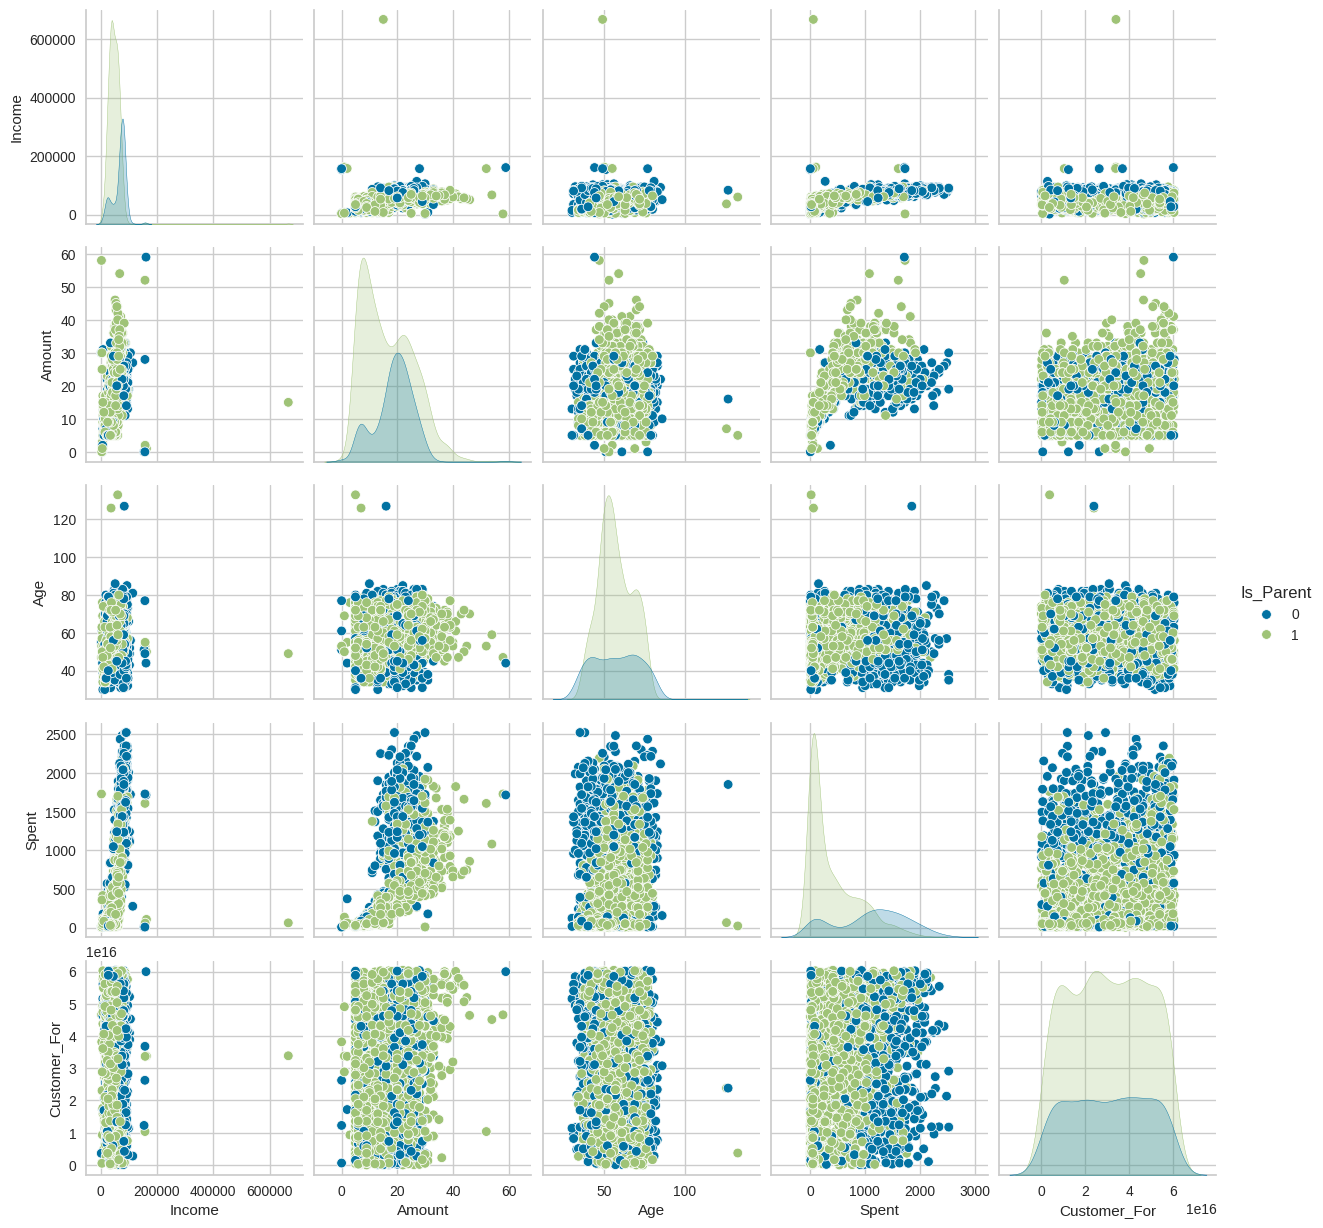

In [ ]:
data_plot = [ "Income", "Amount", "Age", "Spent", "Customer_For", "Is_Parent"]

plt.figure()
sns.pairplot(data[data_plot], hue="Is_Parent")
plt.show()

In [ ]:
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   object 
 1   Marital_Status       2212 non-null   object 
 2   Income               2212 non-null   float64
 3   Kidhome              2212 non-null   int64  
 4   Teenhome             2212 non-null   int64  
 5   Recency              2212 non-null   int64  
 6   MntWines             2212 non-null   int64  
 7   MntFruits            2212 non-null   int64  
 8   MntMeatProducts      2212 non-null   int64  
 9   MntFishProducts      2212 non-null   int64  
 10  MntSweetProducts     2212 non-null   int64  
 11  MntGoldProds         2212 non-null   int64  
 12  NumDealsPurchases    2212 non-null   int64  
 13  NumWebPurchases      2212 non-null   int64  
 14  NumCatalogPurchases  2212 non-null   int64  
 15  NumStorePurchases    2212 non-null   int64 

In [ ]:
objects = (data.dtypes == 'object')
print("Categorical variable in dataset : ", list(objects[objects].index))

Categorical variable in dataset :  ['Education', 'Marital_Status', 'Living_With']


In [ ]:
encoder = LabelEncoder()

for col_name in objects[objects].index:
  data[col_name] = encoder.fit_transform(data[col_name])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Marital_Status       2212 non-null   int64  
 2   Income               2212 non-null   float64
 3   Kidhome              2212 non-null   int64  
 4   Teenhome             2212 non-null   int64  
 5   Recency              2212 non-null   int64  
 6   MntWines             2212 non-null   int64  
 7   MntFruits            2212 non-null   int64  
 8   MntMeatProducts      2212 non-null   int64  
 9   MntFishProducts      2212 non-null   int64  
 10  MntSweetProducts     2212 non-null   int64  
 11  MntGoldProds         2212 non-null   int64  
 12  NumDealsPurchases    2212 non-null   int64  
 13  NumWebPurchases      2212 non-null   int64  
 14  NumCatalogPurchases  2212 non-null   int64  
 15  NumStorePurchases    2212 non-null   int64 

In [ ]:
ds = data.copy()

scaler = StandardScaler()
scaled = scaler.fit_transform(ds)

scaled = pd.DataFrame(scaled, columns=ds.columns)
scaled.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,Complain,Response,Customer_For,Age,Spent,Amount,Living_With,Children,Is_Parent
0,-0.893586,0.254760,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,...,0.692181,-0.09552,2.375425,1.527721,1.018352,1.676245,1.260746,1.349603,-1.264598,-1.581139
1,-0.893586,0.254760,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,...,-0.132545,-0.09552,-0.420977,-1.189011,1.274785,-0.963297,-1.077453,1.349603,1.404572,0.632456
2,-0.893586,1.183144,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,...,-0.544908,-0.09552,-0.420977,-0.206048,0.334530,0.280110,0.559286,-0.740959,-1.264598,-1.581139
3,-0.893586,1.183144,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,...,0.279818,-0.09552,-0.420977,-1.060584,-1.289547,-0.920135,-0.843633,-0.740959,0.069987,0.632456
4,0.571657,-0.673624,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,...,-0.132545,-0.09552,-0.420977,-0.951915,-1.033114,-0.307562,0.793106,-0.740959,0.069987,0.632456


In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(scaled)
print(f"Variance Explained Ratio: {round(sum(pca.explained_variance_ratio_),4 )}")

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df.describe()


Variance Explained Ratio: 0.5021


,PC1,PC2,PC3
count,2.212000e+03,2.212000e+03,2.212000e+03
mean,6.424437e-17,-6.424437e-17,5.621382e-18
std,2.900721e+00,1.738462e+00,1.274525e+00
min,-5.279235e+00,-3.861134e+00,-3.355540e+00
25%,-2.719385e+00,-1.409358e+00,-9.550805e-01
50%,-6.340219e-01,-2.412616e-01,-6.771219e-02
75%,2.581408e+00,1.282241e+00,8.508042e-01
max,7.721123e+00,6.575432e+00,5.522914e+00


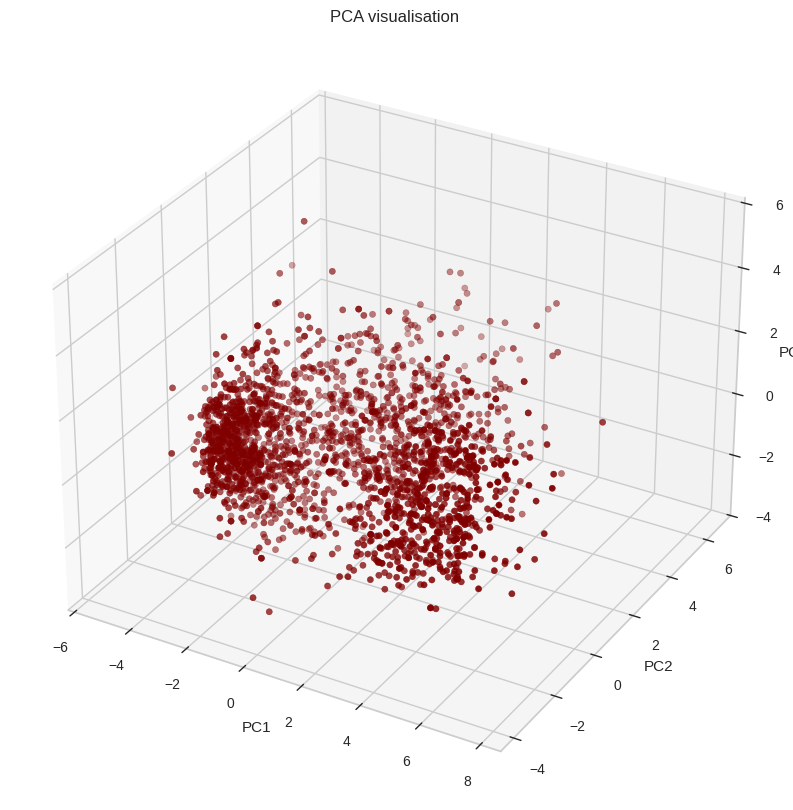

In [ ]:
x = pca_df['PC1']
y = pca_df['PC2']
z = pca_df['PC3']

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c="maroon")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA visualisation")

plt.show()

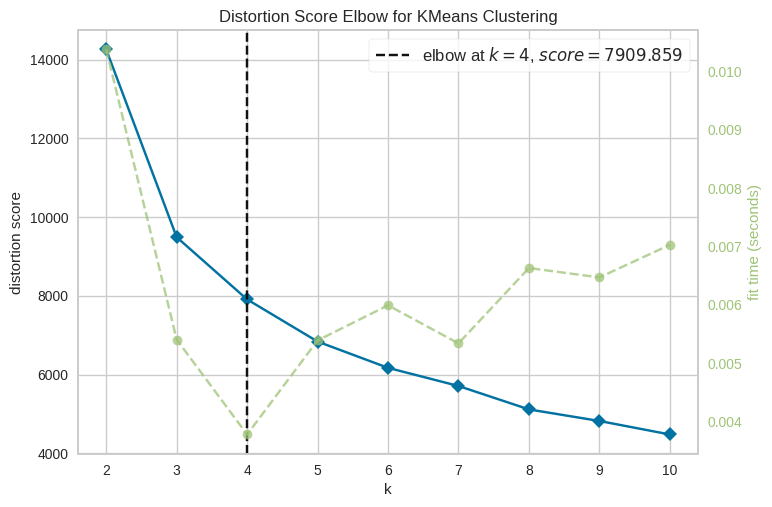

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

elbow_m = KElbowVisualizer(KMeans(), k = 10)
elbow_m.fit(pca_df)
elbow_m.show()

In [ ]:
ac = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = ac.fit_predict(pca_df)
pca_df['Clusters'] = clusters
data["Clusters"] = clusters



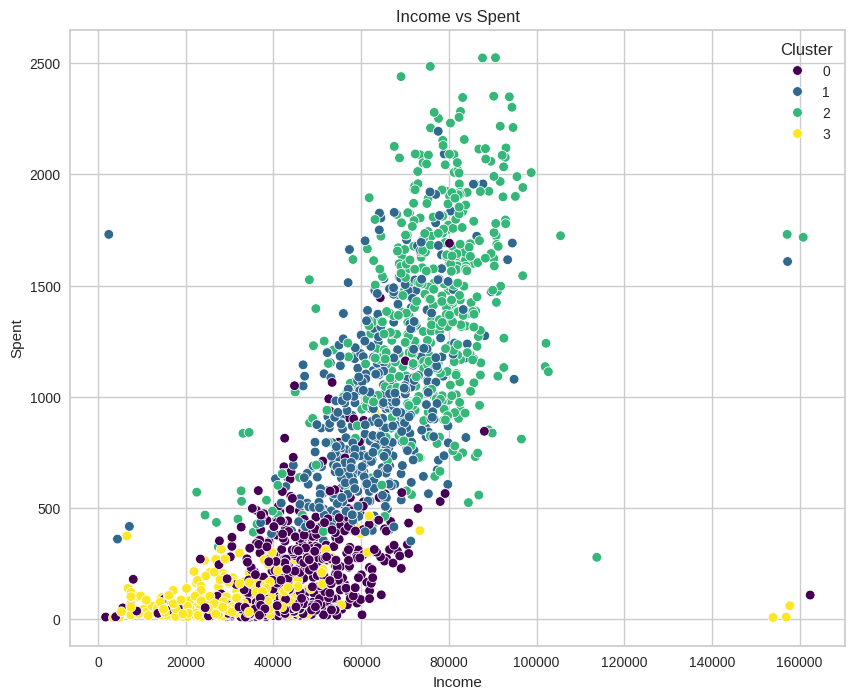

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Income', y='Spent', hue='Clusters', data=data, palette='viridis')
plt.title('Income vs Spent')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()



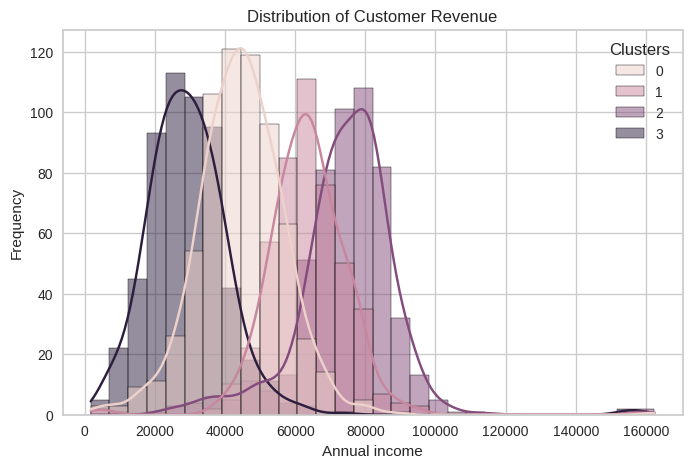

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=data, x="Income", bins=30, kde=True, hue='Clusters')
plt.title("Distribution of Customer Revenue")
plt.xlabel("Annual income")
plt.ylabel("Frequency")
plt.show()

<Figure size 800x550 with 0 Axes>

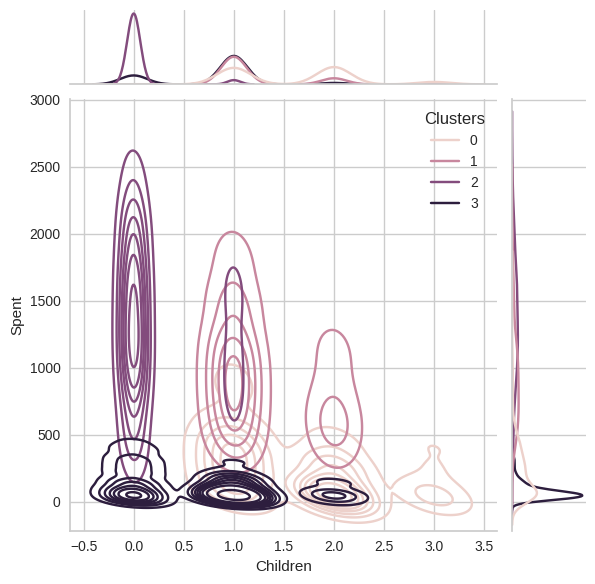

<Figure size 800x550 with 0 Axes>

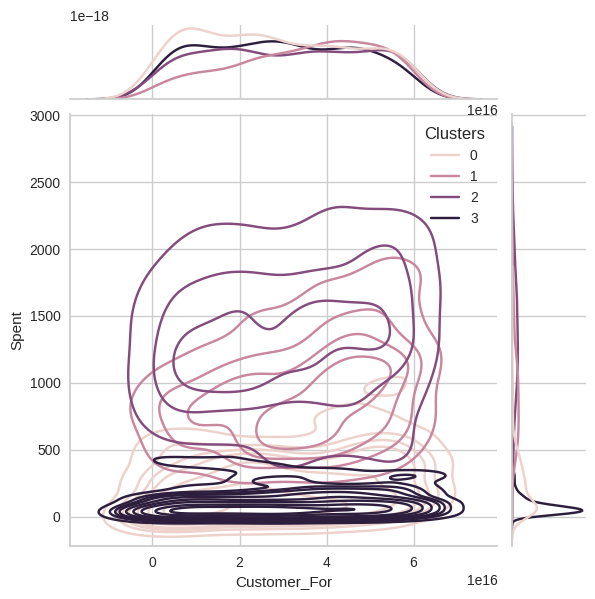

<Figure size 800x550 with 0 Axes>

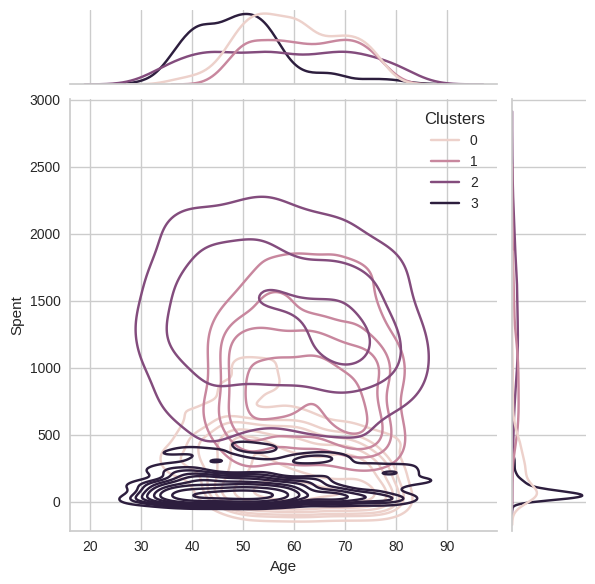

<Figure size 800x550 with 0 Axes>

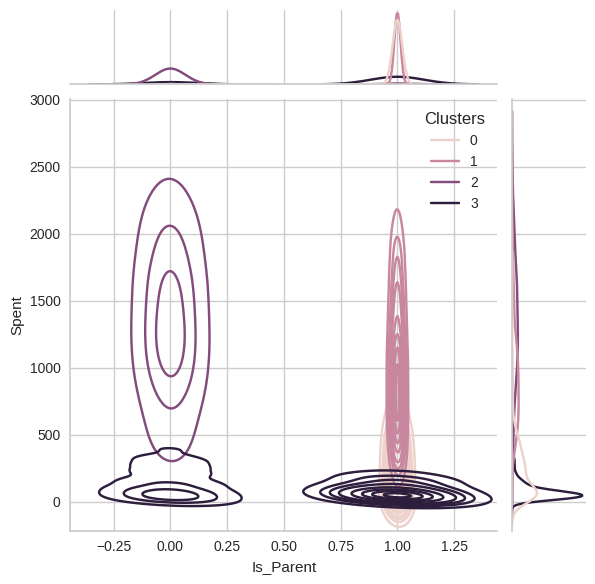

<Figure size 800x550 with 0 Axes>

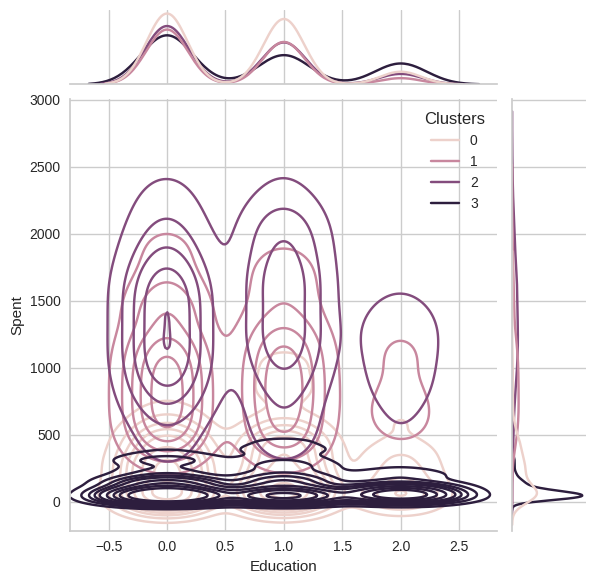

<Figure size 800x550 with 0 Axes>

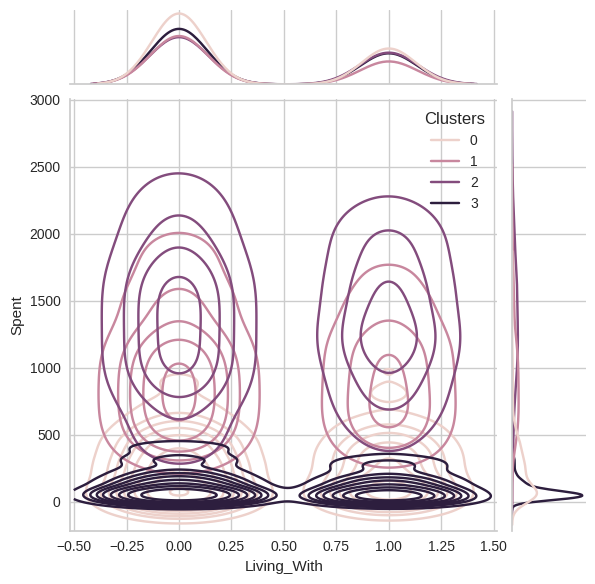

In [ ]:
personal  = ["Children", "Customer_For", "Age", "Is_Parent", "Education", "Living_With"]

for i in personal:
  plt.figure()
  sns.jointplot(x = data[i], y = data["Spent"], hue = data["Clusters"], kind="kde")
  plt.show()